<a href="https://colab.research.google.com/github/MengOonLee/Deep_learning/blob/master/PyTorch/Probabilistic/VAE/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variational autoencoders

## Coding tutorials

#### [1. Encoders and decoders](#tutorial1)
#### [2. Minimising Kullback-Leibler divergence](#tutorial2)
#### [3. Maximising the ELBO](#tutorial3)
#### [4. KL divergence layers](#tutorial4)

In [ ]:
%%bash
pip install --no-cache-dir -qU \
    lightning

***
<a class="anchor" id="tutorial1"></a>
## Encoders and Decoders

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Encoder │  217 K │ train │     0 │
│ 1 │ decoder │ Decoder │  218 K │ train │     0 │
│ 2 │ r2score │ R2Score │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 435 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 435 K                                                                                                
Total estimated model params size (MB): 1.743                                                                      
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Total training time: 7.0448s
Norm of difference: 8.110875129699707


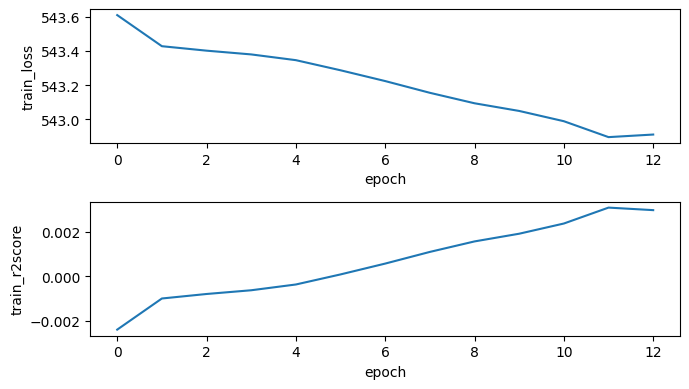

In [ ]:
import os
import torch
import lightning.pytorch as pl
import torchmetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cpus = max(1, os.cpu_count())
pl.seed_everything(seed=42)

class Encoder(torch.nn.Module):
    def __init__(self, latent_dim: int=2):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=28*28, out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=latent_dim)
        )

    def forward(self, x):
        return self.encoder(x)

class Decoder(torch.nn.Module):
    def __init__(self, latent_dim: int=2):
        super().__init__()
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256, out_features=28*28),
            torch.nn.Sigmoid(),
            torch.nn.Unflatten(dim=1, unflattened_size=(28, 28))
        )

    def forward(self, z):
        return self.decoder(z)

class AutoEncoder(pl.LightningModule):
    def __init__(self, encoder: torch.nn.Module, decoder: torch.nn.Module):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.r2score = torchmetrics.regression.R2Score()

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def _compute_loss(self, x, x_hat):
        loss = torch.nn.functional.binary_cross_entropy(
            input=x_hat, target=x, reduction='none')
        return loss.sum(dim=[1, 2]).mean(dim=0)

    def configure_optimizers(self):
        return torch.optim.RMSprop(params=self.parameters(),
            lr=0.001, alpha=0.9)

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self(x)

        loss = self._compute_loss(x=x, x_hat=x_hat)
        self.log('train_loss', loss, on_step=False, on_epoch=True,
            sync_dist=True)

        self.r2score.update(preds=x_hat.view(x_hat.size(0), -1),
            target=x.view(x.size(0), -1))
        self.log('train_r2score', self.r2score, on_step=False,
            on_epoch=True, sync_dist=True)

        return loss

class SyntheticDataModule(pl.LightningDataModule):
    def __init__(self, data_train: torch.Tensor):
        super().__init__()
        self.data_train = data_train

    def setup(self, stage: str=None):
        self.ds_train = torch.utils.data.TensorDataset(
            self.data_train, self.data_train)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(
            dataset=self.ds_train, batch_size=32, shuffle=True,
            pin_memory=False, num_workers=cpus
        )

timer_callback = pl.callbacks.Timer()

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor='train_r2score', mode='max', dirpath='./ckpt/path/'
)

early_stopping_callback = pl.callbacks.EarlyStopping(
    monitor='train_r2score', mode='max', patience=1,
    check_on_train_epoch_end=True
)

csv_logger = pl.loggers.CSVLogger(save_dir='./logs/', name='autoencoder')

trainer = pl.Trainer(max_epochs=20, accelerator='auto',
    logger=csv_logger, enable_progress_bar=False, log_every_n_steps=1,
    callbacks=[timer_callback, checkpoint_callback, early_stopping_callback]
)

if __name__ == '__main__':
    latent_dim = 2
    encoder = Encoder(latent_dim=latent_dim)
    decoder = Decoder(latent_dim=latent_dim)
    model = AutoEncoder(encoder=encoder, decoder=decoder)

    data_train = torch.rand(size=(1000, 28, 28))
    datamodule = SyntheticDataModule(data_train=data_train)

    trainer.fit(model=model, datamodule=datamodule)

train_time = timer_callback.time_elapsed("train")
print(f"Total training time: %.4fs"%(train_time))

metrics_path = os.path.join(csv_logger.log_dir, 'metrics.csv')
df_metrics = pd.read_csv(metrics_path)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 4))
for ax, y in zip(axes, ['train_loss', 'train_r2score']):
    sns.lineplot(ax=ax, data=df_metrics, x='epoch', y=y)
fig.tight_layout()
fig.show()

model = AutoEncoder.load_from_checkpoint(
    checkpoint_path=checkpoint_callback.best_model_path,
    encoder=encoder, decoder=decoder
)

x_sample = torch.rand(size=(1, 28, 28))
model.eval()
with torch.no_grad():
    x_pred = model(x_sample.to(model.device))
x_pred = x_pred.cpu()

diff_norm = torch.norm(input=x_pred - x_sample)
print(f"Norm of difference: {diff_norm.item()}")

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/

In [1]:
!rm -rf lightning_logs/ ckpt/ logs/

In [1]:
import torch
import lightning.pytorch as pl
import torchmetrics

pl.seed_everything(seed=42)

# Define the encoder
class Encoder(torch.nn.Module):
    def __init__(self, latent_dim: int=2):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=28*28, out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=latent_dim)
        )

    def forward(self, x):
        return self.encoder(x)

# Define the decoder
class Decoder(torch.nn.Module):
    def __init__(self, latent_dim: int=2):
        super().__init__()
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256, out_features=28*28),
            torch.nn.Sigmoid(),
            torch.nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
        )

    def forward(self, z):
        return self.decoder(z)

# Autoencoder model
class AutoEncoder(pl.LightningModule):
    def __init__(self, encoder: torch.nn.Module, decoder: torch.nn.Module):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

        self.train_r2score = torchmetrics.regression.R2Score()
        self.val_r2score = torchmetrics.regression.R2Score()
        self.test_r2score = torchmetrics.regression.R2Score()

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def _compute_loss(self, x, x_hat):
        # BCE loss for normalized pixel values [0., 1.],
        loss = torch.nn.functional.binary_cross_entropy(
            input=x_hat, target=x, reduction='none')
        return loss.sum(dim=[1, 2, 3]).mean(dim=0)

    def configure_optimizers(self):
        return torch.optim.Adam(params=self.parameters(), lr=0.001)

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self(x)

        loss = self._compute_loss(x=x, x_hat=x_hat)
        self.log(name='train_loss', value=loss,
            on_step=False, on_epoch=True, sync_dist=True)

        self.train_r2score.update(preds=x_hat.view(-1), target=x.view(-1))
        self.log(name='train_r2score', value=self.train_r2score,
            on_step=False, on_epoch=True, sync_dist=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self(x)

        loss = self._compute_loss(x=x, x_hat=x_hat)
        self.log(name='val_loss', value=loss,
            on_step=False, on_epoch=True, sync_dist=True)

        self.val_r2score.update(preds=x_hat.view(-1), target=x.view(-1))
        self.log(name='val_r2score', value=self.val_r2score,
            on_step=False, on_epoch=True, sync_dist=True)

    def test_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self(x)

        loss = self._compute_loss(x=x, x_hat=x_hat)
        self.log(name='test_loss', value=loss,
            on_step=False, on_epoch=True, sync_dist=True)

        self.test_r2score.update(preds=x_hat.view(-1), target=x.view(-1))
        self.log(name='test_r2score', value=self.test_r2score,
            on_step=False, on_epoch=True, sync_dist=True)

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        return self(x)

latent_dim = 8
encoder = Encoder(latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim)
model = AutoEncoder(encoder=encoder, decoder=decoder)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
100%|██████████| 26.4M/26.4M [00:00<00:00, 111MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.70MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.9MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.47MB/s]


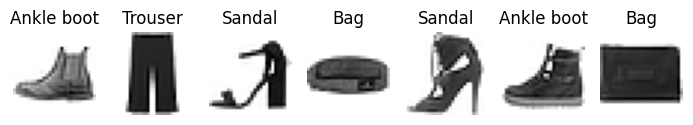

In [2]:
import os
import numpy as np
import torch
import torchvision
import lightning.pytorch as pl
import matplotlib.pyplot as plt

cpus = max(1, os.cpu_count())
pl.seed_everything(seed=42)

class FashionMNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir: str='./data', sample_size: int=1000):
        super().__init__()
        self.data_dir = data_dir
        self.sample_size = sample_size
        self.transform = torchvision.transforms.Compose(transforms=[
            torchvision.transforms.ToTensor()
        ])
        self.ds_train = None
        self.ds_val = None
        self.ds_test = None
        self.ds_sample = None
        self.class_to_idx = None

    def prepare_data(self):
        torchvision.datasets.FashionMNIST(root=self.data_dir, download=True,
            train=True)
        torchvision.datasets.FashionMNIST(root=self.data_dir, download=True,
            train=False)

    def setup(self, stage: str=None):
        if stage=='fit' or stage is None:
            ds = torchvision.datasets.FashionMNIST(root=self.data_dir,
                train=True, transform=self.transform)
            self.class_to_idx = ds.class_to_idx

            self.ds_train, self.ds_val = torch.utils.data.random_split(
                dataset=ds, lengths=[0.9, 0.1],
                generator=torch.Generator().manual_seed(42))

        if stage in ['test', 'predict'] or stage is None:
            self.ds_test = torchvision.datasets.FashionMNIST(
                root=self.data_dir, train=False, transform=self.transform)

            if self.class_to_idx is None:
                self.class_to_idx = self.ds_test.class_to_idx

            indices = torch.randperm(n=len(self.ds_test),
                generator=torch.Generator().manual_seed(42)
            )[:self.sample_size]
            self.ds_sample = torch.utils.data.Subset(dataset=self.ds_test,
                indices=indices)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_train,
            batch_size=32, shuffle=True, num_workers=cpus)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_val,
            batch_size=32, shuffle=False, num_workers=cpus)

    def test_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_test,
            batch_size=32, shuffle=False, num_workers=cpus)

    def predict_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_sample,
            batch_size=self.sample_size, shuffle=False, num_workers=cpus)

if __name__ == '__main__':
    datamodule = FashionMNISTDataModule(sample_size=1000)
    datamodule.prepare_data()
    datamodule.setup()

dl_sample = datamodule.predict_dataloader()
x_sample, y_sample = next(iter(dl_sample))

idx_to_class = {v: k for k, v in datamodule.class_to_idx.items()}
y_sample = np.array([idx_to_class[i] for i in y_sample.numpy()])

fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(7, 3))
for i, ax in enumerate(axes):
    y = y_sample[i]
    ax.set_title(label=y)
    x = x_sample[i].squeeze().numpy()
    ax.imshow(X=x, cmap='binary')
    ax.axis('off')
plt.tight_layout()
plt.show()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder       │ Encoder │  217 K │ train │     0 │
│ 1 │ decoder       │ Decoder │  218 K │ train │     0 │
│ 2 │ train_r2score │ R2Score │      0 │ train │     0 │
│ 3 │ val_r2score   │ R2Score │      0 │ train │     0 │
│ 4 │ test_r2score  │ R2Score │      0 │ train │     0 │
└───┴───────────────┴─────────┴────────┴───────┴───────┘

Trainable params: 436 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 436 K                                                                                                
Total estimated model params size (MB): 1.747                                                                      
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Total training time: 345.5679s


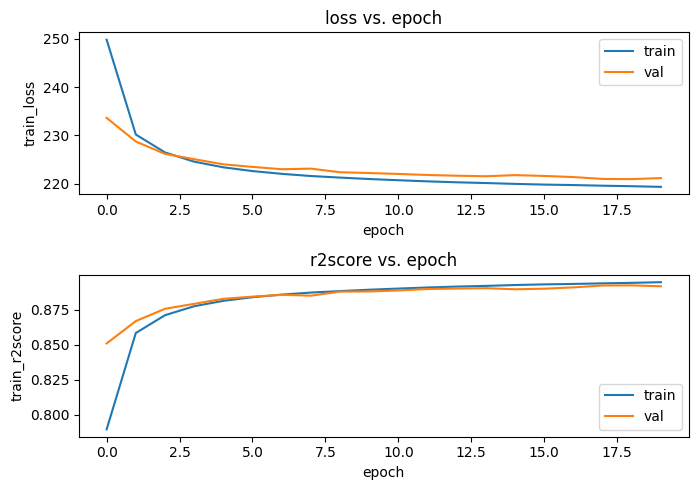

In [3]:
import os
import torch
import lightning.pytorch as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pl.seed_everything(seed=42)

timer_callback = pl.callbacks.Timer()
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor='val_loss', mode='min', dirpath='./AutoEncoder/ckpt/'
)
early_stopping_callback = pl.callbacks.EarlyStopping(
    monitor='val_loss', mode='min', patience=7
)
csv_logger = pl.loggers.CSVLogger(save_dir='./logs/', name='AutoEncoder')

trainer = pl.Trainer(max_epochs=30, accelerator='auto',
    logger=csv_logger, enable_progress_bar=False,
    callbacks=[timer_callback, checkpoint_callback, early_stopping_callback]
)

if __name__ == '__main__':
    trainer.fit(model=model, datamodule=datamodule)

train_time = timer_callback.time_elapsed("train")
print(f"Total training time: %.4fs"%(train_time))

metrics_path = os.path.join(csv_logger.log_dir, 'metrics.csv')
df_metrics = pd.read_csv(metrics_path)
df_metrics = df_metrics.groupby('epoch').agg({
    'train_loss': 'mean', 'train_r2score': 'mean',
    'val_loss': 'mean', 'val_r2score': 'mean'
}).reset_index()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 5))
for ax, m in zip(axes, ['loss', 'r2score']):
    sns.lineplot(ax=ax, data=df_metrics, x='epoch', y=f'train_{m}',
        label='train')
    sns.lineplot(ax=ax, data=df_metrics, x='epoch', y=f'val_{m}',
        label='val')
    ax.set_title(label=f'{m} vs. epoch')
    ax.legend(loc='best')
plt.tight_layout()
plt.show()

model = AutoEncoder.load_from_checkpoint(
    checkpoint_path=checkpoint_callback.best_model_path,
    encoder=encoder, decoder=decoder
)

trainer.test(model=model, datamodule=datamodule)

In [8]:
x_pred = trainer.predict(model=model, datamodule=datamodule)
x_pred = torch.cat(x_pred, dim=0)
x_pred.shape

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


torch.Size([10000, 1, 28, 28])

In [ ]:
import torch
from sklearn import manifold
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(seed=42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder.eval()
with torch.no_grad():
    x = x_sample.to(device)
    z_posttrain = encoder(x).cpu()
z_posttrain = z_posttrain.cpu().numpy()

pca = manifold.TSNE(n_components=2)
z_pretrain = pca.fit_transform(X=z_pretrain)
z_posttrain = pca.fit_transform(X=z_posttrain)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=[15, 7])
sns.scatterplot(ax=axes[0], x=z_pretrain[:, 0], y=z_pretrain[:, 1],
    hue=y_sample, palette=sns.color_palette(palette='colorblind', n_colors=10)
)
sns.scatterplot(ax=axes[1], x=z_posttrain[:, 0], y=z_posttrain[:, 1],
    hue=y_sample, palette=sns.color_palette(palette='colorblind', n_colors=10)
)
axes[0].set_title(label='Latent space before training');
axes[1].set_title(label='Latent space after training');
for ax in axes:
    ax.set_xlabel(xlabel=f"$z_1$")
    ax.set_ylabel(ylabel=f"$z_2$")
fig.tight_layout()
fig.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(seed=42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute the autoencoder's reconstructions
autoencoder.eval()
with torch.no_grad():
    x = x_sample.to(device)
    x_hat = autoencoder(x=x)
x_hat = x_hat.cpu()

# Evaluate the autoencoder's reconstructions
fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(7, 3))
for i in range(7):
    y = y_sample[i]
    axes[0, i].set_title(label=y)

    x = x_sample[i].squeeze().numpy()
    axes[0, i].imshow(X=x, cmap='binary')
    axes[0, i].axis('off')

    x = x_hat[i].squeeze().numpy()
    axes[1, i].imshow(X=x, cmap='binary')
    axes[1, i].axis('off')
fig.tight_layout()
fig.show()

***
<a class="anchor" id="tutorial2"></a>
## Minimising Kullback-Leibler divergence

In [ ]:
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

# KL(q || p) = E_{z ~ q}[log q(z) - log p(z)]

# tfp.bijectors.Chain(bijectors=[
#     tfp.bijectors.TransformDiagonal(diag_bijector=tfp.bijectors.Chain(bijectors=[
#         tfp.bijectors.Shift(shift=1e-5),
#         tfp.bijectors.Softplus()])),
#     tfp.bijectors.FillTriangular()
# ])

scale_tril = tfp.bijectors.FillScaleTriL().forward(x=[-0.5, 1.25, 1.])
p = tfp.distributions.MultivariateNormalTriL(loc=0., scale_tril=scale_tril)

q = tfp.distributions.MultivariateNormalDiag(
    loc=tf.Variable(initial_value=tf.random.normal(shape=[2])),
    scale_diag=tfp.util.TransformedVariable(initial_value=tf.random.uniform(shape=[2]),
        bijector=tfp.bijectors.Exp())
)

@tf.function(reduce_retracing=True)
def loss_and_grads(q, p):
    with tf.GradientTape() as tape:
        loss = tfp.distributions.kl_divergence(distribution_a=q, distribution_b=p)
    grads = tape.gradient(target=loss, sources=q.trainable_variables)
    return loss, grads

opt = tf.keras.optimizers.Adam()
for _ in range(3):
    loss, grads = loss_and_grads(q=q, p=p)
    opt.apply_gradients(grads_and_vars=zip(grads, q.trainable_variables))
    print('loss:', loss)

In [ ]:
# Define a target distribution, p
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

p_mu = 0.
p_L = tfp.bijectors.Chain(bijectors=[
    tfp.bijectors.TransformDiagonal(diag_bijector=tfp.bijectors.Softplus()),
    tfp.bijectors.FillTriangular()
]).forward(x=tf.random.uniform(shape=[3]))
p = tfp.distributions.MultivariateNormalTriL(loc=p_mu, scale_tril=p_L)
p

In [ ]:
# Plot the target distribution's density contours
import numpy as np
np.random.seed(seed=42)
import matplotlib.pyplot as plt

def plot_density_contours(density, X1, X2, contour_kwargs, ax=None):
    '''
    Plots the contours of a bivariate TensorFlow density function
    (i.e. .prob()). X1 and X2 are numpy arrays of mesh coordinates.
    '''
    X = np.hstack([X1.flatten()[:, np.newaxis], X2.flatten()[:, np.newaxis]])
    density_values = np.reshape(a=density(X).numpy(), newshape=X1.shape)

    if ax==None:
        _, ax = plt.subplots(figsize=(4, 4))

    ax.contour(X1, X2, density_values, **contour_kwargs)
    return ax

x1 = np.linspace(start=-5, stop=5, num=1000, dtype=np.float32)
x2 = np.linspace(start=-5, stop=5, num=1000, dtype=np.float32)
X1, X2 = np.meshgrid(x1, x2)
# Density contours are linearly spaced specific to this seed
contour_levels = np.linspace(start=1e-4, stop=10**(-0.8), num=20, dtype=np.float32)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[4, 4])
ax = plot_density_contours(ax=ax, density=p.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'cividis'})
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5);
ax.set_title(label='Density contours of target distribution, $p$')
ax.set_xlabel(xlabel='$x_1$'); ax.set_ylabel(ylabel='$x_2$');
fig.tight_layout()
fig.show()

In [ ]:
# Initialize an approximating distribution, q, that has diagonal covariance
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

q = tfp.distributions.MultivariateNormalDiag(
    loc=tf.Variable(initial_value=tf.random.normal(shape=[2])),
    scale_diag=tfp.util.TransformedVariable(initial_value=tf.random.uniform(shape=[2]),
        bijector=tfp.bijectors.Exp()))
q

In [ ]:
# Define a function for the Kullback-Leibler divergence
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

@tf.function(reduce_retracing=True)
def loss_and_grads(dist_a, dist_b):
    with tf.GradientTape() as tape:
        loss = tfp.distributions.kl_divergence(distribution_a=dist_a,
            distribution_b=dist_b)
    grads = tape.gradient(target=loss, sources=dist_a.trainable_variables)
    return loss, grads

In [ ]:
# Run a training loop that computes KL[q || p], updates q's parameters using its gradients
import numpy as np
np.random.seed(seed=42)
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt
from IPython import display

num_train_steps = 300
opt = tf.keras.optimizers.Adam(learning_rate=.01)
for i in range(num_train_steps):

    # Compute the KL divergence and its gradients
    q_loss, grads = loss_and_grads(dist_a=q, dist_b=p)

    # Update the trainable variables using the gradients via the optimizer
    opt.apply_gradients(grads_and_vars=zip(grads, q.trainable_variables))

    # Plot the updated density
    if ((i + 1) % 10 == 0):
        display.clear_output(wait=True)
        ax = plot_density_contours(density=p.prob, X1=X1, X2=X2,
            contour_kwargs={'levels':contour_levels, 'cmap':'cividis', 'alpha':0.5})
        ax = plot_density_contours(ax=ax, density=q.prob, X1=X1, X2=X2,
            contour_kwargs={'levels':contour_levels, 'cmap':'plasma'})
        ax.set_title(label='Density contours of $p$ and $q$\n' + 'Iteration '
            + str(i + 1) + '\n' + '$D_{KL}[q \ || \ p] = '
            + str(np.round(a=q_loss.numpy(), decimals=4)) + '$', loc='left')
        plt.tight_layout()
        plt.show()
        plt.pause(interval=.01)

In [ ]:
# Re-fit the distribution, this time fitting q_rev by minimising KL[p || q_rev]
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

q_rev = tfp.distributions.MultivariateNormalDiag(
    loc=tf.Variable(initial_value=tf.random.normal(shape=[2])),
    scale_diag=tfp.util.TransformedVariable(initial_value=tf.random.uniform(shape=[2]),
        bijector=tfp.bijectors.Exp()))
q_rev

In [ ]:
# Edit loss_and_grads function
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

@tf.function(reduce_retracing=True)
def loss_and_grads(dist_a, dist_b, reverse=False):
    with tf.GradientTape() as tape:
        if not reverse:
            loss = tfp.distributions.kl_divergence(distribution_a=dist_a,
                distribution_b=dist_b)
        else:
            loss = tfp.distributions.kl_divergence(distribution_a=dist_b,
                distribution_b=dist_a)
    grads = tape.gradient(target=loss, sources=dist_a.trainable_variables)
    return loss, grads

In [ ]:
# Re-initialize optimizer, run training loop
import numpy as np
np.random.seed(seed=42)
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt
from IPython import display

opt = tf.keras.optimizers.Adam(learning_rate=.01)
for i in range(num_train_steps):
    # Reverse the KL divergence terms - compute KL[p || q_rev]
    q_rev_loss, grads = loss_and_grads(dist_a=q_rev, dist_b=p, reverse=True)

    # Update the trainable variables using the gradients via the optimizer
    opt.apply_gradients(grads_and_vars=zip(grads, q_rev.trainable_variables))

    # Plot the updated density
    if ((i + 1) % 10 == 0):
        display.clear_output(wait=True)
        ax = plot_density_contours(density=p.prob, X1=X1, X2=X2,
            contour_kwargs={'levels':contour_levels, 'cmap':'cividis', 'alpha':0.5})
        ax = plot_density_contours(ax=ax, density=q_rev.prob, X1=X1, X2=X2,
            contour_kwargs={'levels':contour_levels, 'cmap':'plasma'})
        ax.set_title(label='Density contours of $p$ and $q_{rev}$\n' + 'Iteration '
            + str(i + 1) + '\n' + '$D_{KL}[p \ || \ q_{rev}] = ' +
            str(np.round(a=q_rev_loss.numpy(), decimals=4)) + '$', loc='left')
        plt.tight_layout()
        plt.show()
        plt.pause(interval=.01)

Exception in thread Thread-20 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

In [ ]:
# Plot q and q_rev alongside one another
import numpy as np
np.random.seed(seed=42)
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=[9, 4])
axs[0] = plot_density_contours(ax=axs[0], density=p.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'cividis', 'alpha':0.5})
axs[0] = plot_density_contours(ax=axs[0], density=q.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'plasma'})
axs[0].set_title(loc='left', label='Density contours of $p$ and $q$\n'
    + '$D_{KL}[q \ || \ p] = ' + str(np.round(a=q_loss.numpy(), decimals=4)) + '$')

axs[1] = plot_density_contours(ax=axs[1], density=p.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'cividis', 'alpha':0.5})
axs[1] = plot_density_contours(ax=axs[1], density=q_rev.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'plasma'})
axs[1].set_title(loc='left', label='Density contours of $p$ and $q_{rev}$\n' +
    '$D_{KL}[p \ || \ q_{rev}] = ' + str(np.round(a=q_rev_loss.numpy(), decimals=4)) + '$');

---
<a class="anchor" id="tutorial3"></a>
## Maximising the ELBO

Review of terminology:
- $p(z)$ = prior
- $q(z|x)$ = encoding distribution
- $p(x|z)$ = decoding distribution

\begin{align*}
\log p(x) &\geq \mathbb{E}_{Z \sim q(z|x)}\big[\ −\log q(Z|x) + \log p(x, Z) \ \big]\\
&= - \mathrm{D}_\mathrm{KL}\big[\ q(z|x) \ || \ p(z) \ \big] + \mathbb{E}_{Z \sim q(z|x)}\big[ \log p(x|Z) \big]
\end{align*}

In [ ]:
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# encoder(x) = q(z|x) ~= p(z|x)
# z ~ N(0, I) = p(z)
# p(x|z) = decode(z)
# x ~ p(x|z)

# log p(x) >= E_{z ~ q(z|x)}[-log q(z|x) + log p(x, z)]
# = -D_{KL}(q(z|x) || p(z)) + E_{z ~ q(z|x)}[log p(x|z)] (ELBO)

latent_size = 2
event_shape = [28, 28, 1]
encoder = tf_keras.Sequential(name='encoder', layers=[
    tf_keras.Input(shape=event_shape),
    tf_keras.layers.Conv2D(filters=8, kernel_size=[5, 5], strides=2,
        activation=tf.keras.activations.tanh),
    tf_keras.layers.Conv2D(filters=8, kernel_size=[5, 5], strides=2,
        activation=tf.keras.activations.tanh),
    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.tanh),
    tf_keras.layers.Dense(units=2*latent_size),
    tfp.layers.DistributionLambda(make_distribution_fn=lambda t:
        tfp.distributions.MultivariateNormalDiag(loc=t[..., :latent_size],
            scale_diag=tf.math.exp(x=t[..., latent_size:])))
])
decoder = tf_keras.Sequential(name='decoder', layers=[
    tf_keras.Input(shape=latent_size),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.tanh),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.tanh),
    tf_keras.layers.Reshape(target_shape=[4, 4, 8]),
    tf_keras.layers.Conv2DTranspose(filters=8, kernel_size=[5, 5], strides=2,
        output_padding=1, activation=tf.keras.activations.tanh),
    tf_keras.layers.Conv2DTranspose(filters=8, kernel_size=[5, 5], strides=2,
        output_padding=1, activation=tf.keras.activations.tanh),
    tf_keras.layers.Conv2D(filters=1, kernel_size=[3, 3], padding='SAME'),
    tf_keras.layers.Flatten(),
    tfp.layers.IndependentBernoulli(event_shape=event_shape)
])

prior = tfp.distributions.MultivariateNormalDiag(loc=tf.zeros(shape=latent_size))

def loss_fn(x_true, approx_posterior, x_pred, prior_dist):
    reconstruction_loss = -x_pred.log_prob(value=x_true)
    kl_loss = tfp.distributions.kl_divergence(distribution_a=approx_posterior,
        distribution_b=prior_dist)
    return tf.math.reduce_mean(input_tensor=kl_loss + reconstruction_loss)

# Monte Carlo
def loss_fn_MC(x_true, approx_posterior, x_pred, prior_dist):
    reconstruction_loss = -x_pred.log_prob(value=x_true)
    approx_posterior_sample = approx_posterior.sample()
    kl_approx = (approx_posterior.log_prob(value=approx_posterior_sample)
        - prior_dist.log_prob(value=approx_posterior_sample))
    return tf.math.reduce_mean(input_tensor=kl_approx + reconstruction_loss)

@tf.function(reduce_retracing=True)
def get_loss_and_grads(x, encoder, decoder, prior):
    with tf.GradientTape() as tape:
        approx_posterior = encoder(inputs=x)
        approx_posterior_sample = approx_posterior.sample()
        x_pred = decoder(inputs=approx_posterior_sample)
        loss = loss_fn(x_true=x, approx_posterior=approx_posterior,
            x_pred=x_pred, prior_dist=prior)
    grads = tape.gradient(target=loss, sources=
        encoder.trainable_variables + decoder.trainable_variables)
    return loss, grads

x_train = tf.random.normal(shape=[64, 28, 28, 1], dtype=tf.float32)
x_train = tf.data.Dataset.from_tensor_slices(tensors=x_train).batch(batch_size=32)

opt = tf_keras.optimizers.Adam()
for i in range(3):
    for x in x_train:
        loss, grads = get_loss_and_grads(x=x, encoder=encoder, decoder=decoder,
            prior=prior)
        opt.apply_gradients(grads_and_vars=zip(grads,
            encoder.trainable_variables + decoder.trainable_variables))
    print('-ELBO after epoch %d: %.2f'%(i+1, loss.numpy()))

z = prior.sample(sample_shape=[3]) #(3, 2)
x_generated = decoder(inputs=z).sample() #(3, 28, 28, 1)
print('Generated shape:', x_generated.shape)

def vae(inputs):
    approx_posterior = encoder(inputs=inputs)
    decoded = decoder(inputs=approx_posterior.sample())
    return decoded.mean()

x_test = tf.random.normal(shape=[1, 28, 28, 1], dtype=tf.float32)
z = encoder(inputs=x_test) #(1, 28, 28, 1)
x_decoded = decoder(inputs=z.sample()).mean()

reconstruction = vae(inputs=x_test) #(1, 28, 28, 1)
tf.norm(tensor=reconstruction - x_decoded)

In [ ]:
# Import Fasion MNIST, make it a TensorFlow Dataset
import numpy as np
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
example_x = x_test[:1000]
example_y = y_test[:1000]

class_names = np.array(['T-shirt/top', 'Trouser/pants', 'Pullover shirt',
    'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

batch_size = 64
x_train = tf.data.Dataset.from_tensor_slices(tensors=x_train)\
    .batch(batch_size=batch_size)

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=[9, 1])
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X=example_x[i], cmap='binary')
    ax.axis('off')
fig.tight_layout()
fig.show()

In [ ]:
# Define the encoding distribution, q(z|x)
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

latent_size = 2
event_shape = [28, 28]
encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=event_shape),
    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(units=256, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=2*latent_size),
    tfp.layers.DistributionLambda(make_distribution_fn=lambda t:
        tfp.distributions.MultivariateNormalDiag(loc=t[..., :latent_size],
            scale_diag=tf.math.exp(x=t[..., latent_size:])))
])

# Pass an example image through the network - should return a batch of MultivariateNormalDiags.
pretrain_example_encodings = encoder(inputs=example_x)
pretrain_example_encodings

In [ ]:
# Define the decoding distribution, p(x|z)
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

decoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=latent_size),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=256, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.IndependentBernoulli.params_size(
        event_shape=event_shape)),
    tfp.layers.IndependentBernoulli(event_shape=event_shape)
])

# Pass a batch of examples to the decoder
decoder(inputs=pretrain_example_encodings)

In [ ]:
# Define the prior, p(z) - a standard bivariate Gaussian
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

prior = tfp.distributions.MultivariateNormalDiag(loc=tf.zeros(shape=latent_size))
prior

The loss function we need to estimate is

\begin{equation*}
-\mathrm{ELBO} = \mathrm{D}_\mathrm{KL} \big[ \ q(z|x) \ || \ p(z) \ \big] - \mathbb{E}_{Z \sim q(z|x)}\big[ \log p(x|Z) \big]\\
\end{equation*}

where $x = (x_1, x_2, \ldots, x_n)$ refers to all observations, $z = (z_1, z_2, \ldots, z_n)$ refers to corresponding latent variables.

Assumed independence of examples implies that we can write this as

\begin{equation*}
\sum_j \mathrm{D}_\mathrm{KL} \big[ \ q(z_j|x_j) \ || \ p(z_j) \ ] - \mathbb{E}_{Z_j \sim q(z_j|x_j)}\big[ \log p(x_j|Z_j) \big]
\end{equation*}

In [ ]:
# Specify the loss function, an estimate of the -ELBO
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

def loss_fn(x, encoding_dist, sampled_decoding_dist, prior):
    recon_loss = -sampled_decoding_dist.log_prob(value=x)
    kl_loss = tfp.distributions.kl_divergence(distribution_a=encoding_dist,
        distribution_b=prior)
    return tf.math.reduce_sum(input_tensor=kl_loss + recon_loss)

# -ELBO estimate using an estimate of the KL divergence
def loss_fn_MC(x, encoding_dist, sampled_decoding_dist, prior, sampled_z):
    recon_loss = -sampled_decoding_dist.log_prob(value=x)
    kl_approx = (encoding_dist.log_prob(value=sampled_z) - prior.log_prob(value=sampled_z))
    return tf.math.reduce_sum(input_tensor=kl_approx + recon_loss)

In [ ]:
# Define a function that returns the loss and its gradients
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

@tf.function(reduce_retracing=True)
def get_loss_and_grads(x, encoder, decoder, prior):
    with tf.GradientTape() as tape:
        encoding_dist = encoder(inputs=x)
        sampled_z = encoding_dist.sample()
        sampled_decoding_dist = decoder(inputs=sampled_z)
        loss = loss_fn(x=x, encoding_dist=encoding_dist,
            sampled_decoding_dist=sampled_decoding_dist, prior=prior)

    grads = tape.gradient(target=loss, sources=
        encoder.trainable_variables + decoder.trainable_variables)
    return loss, grads

In [ ]:
# Compile and train the model
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

num_epochs = 10
opt = tf_keras.optimizers.Adam()
losses = []
for i in range(num_epochs):
    for train_batch in x_train:
        loss, grads = get_loss_and_grads(x=train_batch, encoder=encoder,
            decoder=decoder, prior=prior)
        opt.apply_gradients(grads_and_vars=zip(grads,
            encoder.trainable_variables + decoder.trainable_variables))
    losses.append(loss.numpy())

plt.figure(figsize=[6, 3])
plt.plot(losses)
plt.xlabel(xlabel='Epochs')
plt.ylabel(ylabel='-ELBO')
plt.title(label='-ELBO vs. Epochs')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute example encodings after training
posttrain_example_encodings = encoder(inputs=example_x)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=[15, 7])
sns.scatterplot(ax=axes[0], hue=class_names[example_y],
    x=pretrain_example_encodings[:, 0], y=pretrain_example_encodings[:, 1],
    palette=sns.color_palette(palette='colorblind', n_colors=10))
sns.scatterplot(ax=axes[1], hue=class_names[example_y],
    x=posttrain_example_encodings[:, 0], y=posttrain_example_encodings[:, 1],
    palette=sns.color_palette(palette='colorblind', n_colors=10))
axes[0].set_title(label='Encodings of example images before training')
axes[1].set_title(label='Encodings of example images after training')
for ax in axes:
    ax.set_xlabel(xlabel='Encoding dimension 1')
    ax.set_ylabel(ylabel='Encoding dimension 2')
fig.tight_layout()
fig.show()

In [ ]:
# Connect encoder and decoder, compute a reconstruction
def vae(inputs):
    approx_posterior = encoder(inputs=inputs)
    decoding_dist = decoder(inputs=approx_posterior.sample())
    return decoding_dist.mean()

example_reconstruction = vae(inputs=example_x)
example_reconstruction.shape

In [ ]:
# Plot examples against reconstructions
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=6, figsize=[9, 2])
for j in range(6):
    axs[0, j].imshow(X=example_x[j], cmap='binary')
    axs[1, j].imshow(X=example_reconstruction[j], cmap='binary')
    axs[0, j].axis('off')
    axs[1, j].axis('off')
fig.tight_layout()
fig.show()

In [ ]:
# Generate an example - sample a z value, then sample a reconstruction from p(x|z)
z = prior.sample(sample_shape=(6))
generated_x = decoder(inputs=z).mean()
generated_x.shape

In [ ]:
# Display generated_x
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=6, figsize=[9, 1])
for j in range(6):
    axs[j].imshow(X=generated_x[j], cmap='binary')
    axs[j].axis('off')
fig.tight_layout()
fig.show()

***
<a class="anchor" id="tutorial4"></a>
# KL divergence layers

In [ ]:
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

latent_size = 4
prior = tfp.distributions.MultivariateNormalDiag(loc=tf.zeros(shape=latent_size))

# approx_posterior.log_prob(value=approx_posterior_sample)
# - prior.log_prob(approx_posterior_sample)
# encoder = tf_keras.Sequential(layers=[
#     tf_keras.Input(shape=12),
#     tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
#     tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL.params_size(
#         event_size=latent_size)),
#     tfp.layers.MultivariateNormalTriL(event_size=latent_size,
#         convert_to_tensor_fn=tfp.distributions.Distribution.sample),
#     tfp.layers.KLDivergenceAddLoss(distribution_b=prior, use_exact_kl=False,
#         weight=10, test_points_fn=lambda q: q.sample(sample_shape=10),
#         test_points_reduce_axis=0) # None, ()
# ])

encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=12),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL
        .params_size(event_size=latent_size)),
    tfp.layers.MultivariateNormalTriL(event_size=latent_size, activity_regularizer=
        tfp.layers.KLDivergenceRegularizer(distribution_b=prior, use_exact_kl=False,
            weight=10, test_points_fn=lambda q: q.sample(sample_shape=10),
            test_points_reduce_axis=0)) # None, ()
])

decoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=latent_size),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.IndependentNormal
        .params_size(event_shape=12)),
    tfp.layers.IndependentNormal(event_shape=12)
])

vae = tf_keras.Model(inputs=encoder.input, outputs=decoder(inputs=encoder.output))
vae.compile(
    loss=lambda x, pred: -pred.log_prob(value=x),
    optimizer=tf_keras.optimizers.Adam()
)

x_train = tf.random.normal(shape=[1000, 12], dtype=tf.float32)
x_train = tf.data.Dataset.from_tensor_slices(tensors=x_train)\
    .map(lambda x: (x, x)).batch(batch_size=32)
history = vae.fit(x=x_train, epochs=20, verbose=False)
train_loss = history.history['loss']

plt.figure(figsize=[6, 3])
plt.plot(train_loss)
plt.xlabel(xlabel='Epochs')
plt.ylabel(ylabel='loss')
plt.title(label='Loss vs. Epochs')
plt.tight_layout()
plt.show()

x_test = tf.random.normal(shape=[1, 12], dtype=tf.float32)
x_pred = vae(inputs=x_test).mean()
tf.norm(tensor=x_pred - x_test)

In [ ]:
# Import Fashion MNIST
import numpy as np
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32')/256. + 0.5/256
x_test = x_test.astype('float32')/256. + 0.5/256
example_x = x_test[:1000]
example_y = y_test[:1000]

class_names = np.array(['T-shirt/top', 'Trouser/pants', 'Pullover shirt',
    'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

batch_size = 32
x_train = tf.data.Dataset.from_tensor_slices(tensors=(x_train, x_train))\
    .batch(batch_size=batch_size)
x_test = tf.data.Dataset.from_tensor_slices(tensors=(x_test, x_test))\
    .batch(batch_size=batch_size)

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=[9, 1])
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X=example_x[i], cmap='binary')
    ax.axis('off')
fig.tight_layout()
fig.show()

In [ ]:
# Define latent_size and the prior, p(z)
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

latent_size = 4
prior = tfp.distributions.MultivariateNormalDiag(loc=tf.zeros(shape=latent_size))
prior

In [ ]:
# Define the encoding distribution using a tfpl.KLDivergenceAddLoss layer
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

# samples z_j from q(z|x_j)
# then computes log q(z_j|x_j) - log p(z_j)
event_shape = [28, 28]
encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=event_shape),
    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=16, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL
        .params_size(event_size=latent_size)),
    tfp.layers.MultivariateNormalTriL(event_size=latent_size),
    # estimates KL[q(z|x)||p(z)]
    tfp.layers.KLDivergenceAddLoss(distribution_b=prior)
])

# See how `KLDivergenceAddLoss` affects `encoder.losses`
# encoder.losses before the network has received any inputs
encoder.losses

In [ ]:
# Pass a batch of images through the encoder
encoder(inputs=example_x)
# See how encoder.losses has changed
encoder.losses

In [ ]:
# Re-specify the encoder using `weight` and `test_points_fn`
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=event_shape),
    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=16, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL
        .params_size(event_size=latent_size)),
    tfp.layers.MultivariateNormalTriL(event_size=latent_size),
    tfp.layers.KLDivergenceAddLoss(distribution_b=prior, use_exact_kl=False,
        weight=1.5, test_points_fn=lambda q: q.sample(sample_shape=10),
        test_points_reduce_axis=0) # estimates KL[q(z|x)||p(z)]
])

# (n_samples, batch_size, dim_z)
# z_{ij} is the ith sample for x_j (is at (i,j,:) in tensor of samples)
# is mapped to log q(z_{ij}|x_j) - log p(z_{ij})
# => tensor of KL divergences has shape (n_samples, batch_size)

# Pass a batch of images through the encoder
encoder(inputs=example_x)
# See how encoder.losses has changed
encoder.losses

In [ ]:
# Replacing `KLDivergenceAddLoss`  with `KLDivergenceRegularizer` in the previous (probabilistic) layer
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

divergence_regularizer = tfp.layers.KLDivergenceRegularizer(distribution_b=prior,
    use_exact_kl=False, test_points_fn=lambda q: q.sample(sample_shape=5),
    test_points_reduce_axis=0)

event_shape = [28, 28]
encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=event_shape),
    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=16, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL
        .params_size(event_size=latent_size)),
    tfp.layers.MultivariateNormalTriL(event_size=latent_size,
        activity_regularizer=divergence_regularizer)
])

# Pass a batch of images through the encoder
encoder(inputs=example_x)
# See how encoder.losses has changed
encoder.losses

In [ ]:
# Specify the decoder, p(x|z)
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

decoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=latent_size),
    tf_keras.layers.Dense(units=16, activation=tf.keras.activations.sigmoid),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.sigmoid),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.sigmoid),
    tf_keras.layers.Dense(units=2*event_shape[0]*event_shape[1],
        activation=tf.keras.activations.exponential),
    tf_keras.layers.Reshape(target_shape=(event_shape[0], event_shape[1], 2)),
    tfp.layers.DistributionLambda(make_distribution_fn=lambda t:
        tfp.distributions.Independent(distribution=tfp.distributions.Beta(
            concentration1=t[..., 0], concentration0=t[..., 1]),
            reinterpreted_batch_ndims=2))
])

decoder(inputs=encoder(inputs=example_x))

In [ ]:
# Connect the encoder and decoder to form the VAE
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

vae = tf_keras.Model(inputs=encoder.inputs, outputs=decoder(inputs=encoder.outputs))

# Define a loss that only estimates the expected reconstruction error,
# -E_{Z ~ q(z|x)}[log p(x|Z)]
def log_loss(x_true, p_x_given_z):
    return -tf.math.reduce_sum(input_tensor=p_x_given_z.log_prob(value=x_true))

# Compile the model
vae.compile(loss=log_loss, optimizer=tf_keras.optimizers.Adam())

In [ ]:
import matplotlib.pyplot as plt

# Fit the model
history = vae.fit(x=x_train, validation_data=x_test, epochs=10, verbose=False)
train_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.figure(figsize=[6, 3])
plt.plot(train_loss, label='train')
plt.plot(val_loss, label='val')
plt.xlabel(xlabel='Epochs')
plt.ylabel(ylabel='loss')
plt.title(label='Loss vs. Epochs')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Generate an example reconstruction
example_reconstruction = vae(inputs=example_x).mean()
example_reconstruction.shape

In [ ]:
# Plot the example reconstructions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=6, figsize=[9, 2])
for j in range(6):
    axes[0, j].imshow(X=example_x[j], cmap='binary')
    axes[1, j].imshow(X=example_reconstruction[j], cmap='binary')
    axes[0, j].axis('off')
    axes[1, j].axis('off')
fig.tight_layout()
fig.show()